# **Dimension Reductionality (PCA, LDA)**

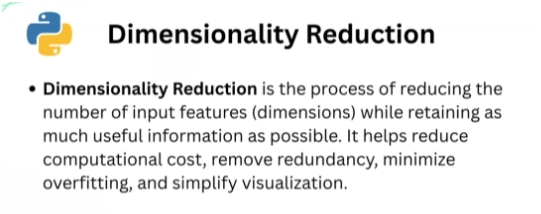

**PCA = Principal Component Analysis**

**LDA = Linear Discriminant Analysis**

# **PCA**

- PCA is unsupervised whereas LDA is supervised
- it only input data is monitored
- Example: price of houses


**step for PCA:**
- calculate mean of the every features
- calculate the covariance matrix
- calculate the eigen values and eigen vectors
- choose principle components
- projected data onto principle components

In [1]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

**load dataset**

In [2]:
df = sns.load_dataset("titanic")
df.sample(5)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
411,0,3,male,NaN,0,0,6.8583,Q,Third,man,True,NaN,Queenstown,no,True
383,1,1,female,35.0,1,0,52.0000,S,First,woman,False,NaN,Southampton,yes,False
47,1,3,female,NaN,0,0,7.7500,Q,Third,woman,False,NaN,Queenstown,yes,True
748,0,1,male,19.0,1,0,53.1000,S,First,man,True,D,Southampton,no,False
203,0,3,male,45.5,0,0,7.2250,C,Third,man,True,NaN,Cherbourg,no,True


**column names**

In [3]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

**select numerical features**

In [4]:
X = df[["pclass","age","sibsp","parch","fare"]]

**filling missing values**

In [5]:
X = X.fillna(X.mean())

**Standardizing the data**

In [6]:
scaler = StandardScaler()

In [8]:
X_scaled = scaler.fit_transform(X)
X_scaled

array([[ 0.82737724, -0.5924806 ,  0.43279337, -0.47367361, -0.50244517],
       [-1.56610693,  0.63878901,  0.43279337, -0.47367361,  0.78684529],
       [ 0.82737724, -0.2846632 , -0.4745452 , -0.47367361, -0.48885426],
       ...,
       [ 0.82737724,  0.        ,  0.43279337,  2.00893337, -0.17626324],
       [-1.56610693, -0.2846632 , -0.4745452 , -0.47367361, -0.04438104],
       [ 0.82737724,  0.17706291, -0.4745452 , -0.47367361, -0.49237783]])

**Applying PCA**

In [9]:
pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X_scaled)

In [11]:
pca_df = pd.DataFrame(X_pca,columns = ["PC1","PC2"])
pca_df

,PC1,PC2
0,1.150803,-0.069191
1,-1.758606,0.142885
2,0.889439,-0.718299
3,-1.448581,0.081721
4,0.574460,-0.939013
...,...,...
886,-0.016893,-0.639964
887,-0.744432,-0.251422
888,0.787938,1.399087
889,-0.988317,-0.423810


**Converting into 3 D**

In [12]:
pca = PCA(n_components = 3)
X_pca = pca.fit_transform(X_scaled)

In [13]:
pca_df = pd.DataFrame(X_pca,columns = ["PC1","PC2","PC3"])
pca_df.sample(5)

,PC1,PC2,PC3
441,1.080683,-0.558840,-0.592561
281,0.820558,-0.768078,-0.086649
874,-0.061681,-0.027282,-0.169633
81,0.767117,-0.780482,-0.035984
816,0.993961,-0.644418,-0.396339


**LDA (Linear Discriminant Analysis)**

- supervised machine learning algorithm primarily used to dimensionality reduction and classification tasks
- goal: to find linear combination of features that maximizes the seperation of class while minimizing the spread(variance) within each class
  - {maximizes mean difference and minimizes within class scatter}

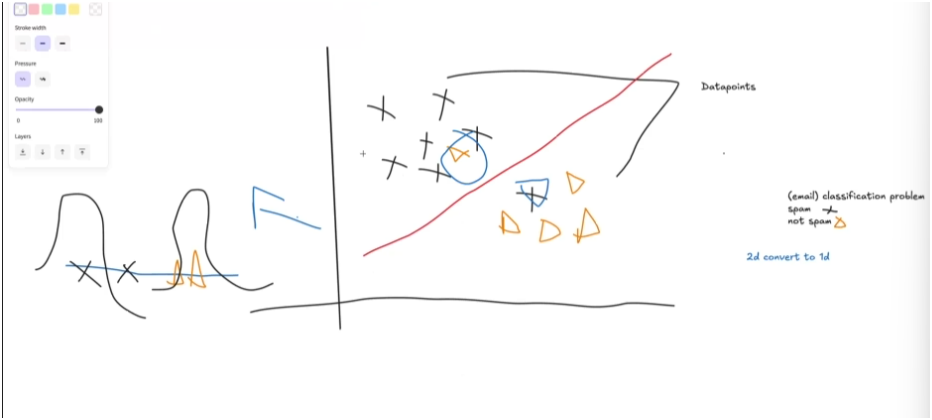

**steps for LDA**
- calculate the mean vectors for each class
- compute covariance of each class
- compute within class scatter matrix
- compute the between class scatter matrix
- find eigen values and choose top eigen values
- find the eigen vectors
- find the dot product of data points with eigen vector

In [15]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [17]:
lda = LinearDiscriminantAnalysis(n_components = 1)

In [18]:
y = df["survived"]

In [19]:
X_lda = lda.fit_transform(X_scaled,y)

In [20]:
lda_df = pd.DataFrame(X_lda,columns = ["LD1"])
lda_df.sample(5)

,LD1
357,-0.052071
808,-0.094375
461,-1.049993
838,-0.755092
528,-1.262057


**Class task: Load Iris dataset and perform:**
- **PCA**
- **LDA**

In [22]:
iris_df = sns.load_dataset("iris")

In [23]:
iris_df.sample(5)

,sepal_length,sepal_width,petal_length,petal_width,species
132,6.4,2.8,5.6,2.2,virginica
98,5.1,2.5,3.0,1.1,versicolor
2,4.7,3.2,1.3,0.2,setosa
71,6.1,2.8,4.0,1.3,versicolor
14,5.8,4.0,1.2,0.2,setosa


**selecting input columns and output columns**

In [24]:
X = iris_df[["sepal_length","sepal_width","petal_length","petal_width"]]
y = iris_df["species"]

**importing StandardScaler and LabelEncoder**

In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

In [26]:
scaler = StandardScaler()
encoder = LabelEncoder()

In [27]:
X_scaled = scaler.fit_transform(X)
y_encoded = encoder.fit_transform(y)

**importing PCA and LDA**

In [28]:
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [29]:
pca = PCA(n_components = 2)
lda = LinearDiscriminantAnalysis(n_components = 2)

**PCA**

In [32]:
X_pca = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(X_pca,columns = ["PC1","PC2"])
pca_df.sample(5)

,PC1,PC2
88,0.069588,-0.219503
104,1.867812,0.295045
60,-0.110196,-2.654073
134,1.202473,-0.811315
59,0.011426,-1.034018


**LDA**

In [34]:
X_lda = lda.fit_transform(X_scaled,y_encoded)
lda_df = pd.DataFrame(X_lda,columns = ["LD1","LD2"])
lda_df.sample(5)

,LD1,LD2
145,-5.645003,-1.677717
114,-6.759263,-1.600232
23,6.251404,-0.439696
12,7.326796,1.072989
11,7.219297,0.109646


**Explained Variance**

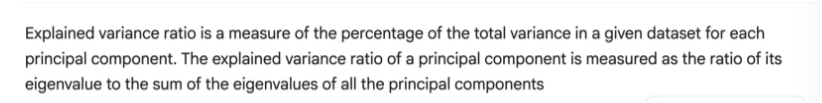

In [35]:
print("\nExplained variance Ratio:")
print(pca.explained_variance_ratio_)


Explained variance Ratio:
[0.72962445 0.22850762]
